In [431]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [432]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [433]:
from astropy.io import fits
with fits.open('astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

In [434]:
twoprocess_df = fits_to_pandas("astroNN_2proc_crossmatch.fits", hdu=2)
astronn_df = fits_to_pandas("astroNN_2proc_crossmatch.fits", hdu=1)
JOKER_df = fits_to_pandas("apJoker-metadata.fits")
adrian_df = fits_to_pandas("allStar-dr17-synspec_rev1-GaiaDR3-EDR3_STARHORSE_v2-MilkyWayPotential2022-staeckel.fits")
astronn_df['MG_FE'] = astronn_df['MG_H'] - astronn_df['FE_H']
twoprocess_df['A_CC/A_IA'] = twoprocess_df['A_CC']/twoprocess_df['A_IA']
twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] > 0]
twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] < 10]

data = (
    adrian_df
    .merge(twoprocess_df, on="APOGEE_ID", how="inner")
    .merge(astronn_df, on="APOGEE_ID", how="inner")
)

data = data.dropna()

data['A_CC/A_IA'] = data['A_CC']/data['A_IA']
data['A_IA/A_CC'] = data['A_IA']/data['A_CC']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "red"
data_low_alpha['color'] = "blue"

merged = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

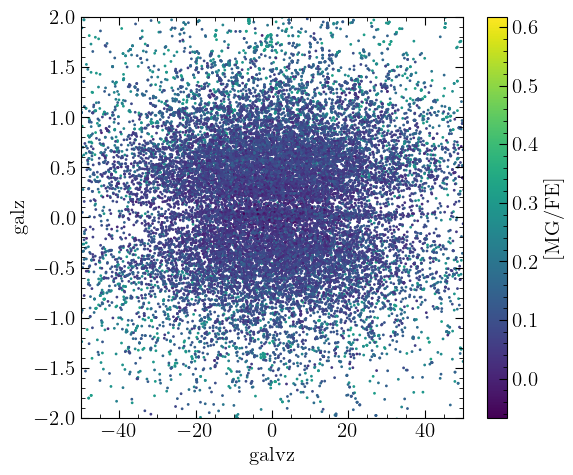

In [435]:
plt.figure(figsize=(6,5))

plt.scatter(
    merged['galvz'],
    merged['galz'],
    c=merged['MG_FE'],   
    cmap='viridis' ,
    s = 1         
)

plt.xlim(-50,50)
plt.ylim(-2,2)

plt.colorbar(label='[MG/FE]')
plt.xlabel('galvz')
plt.ylabel('galz')
plt.tight_layout()
plt.show()


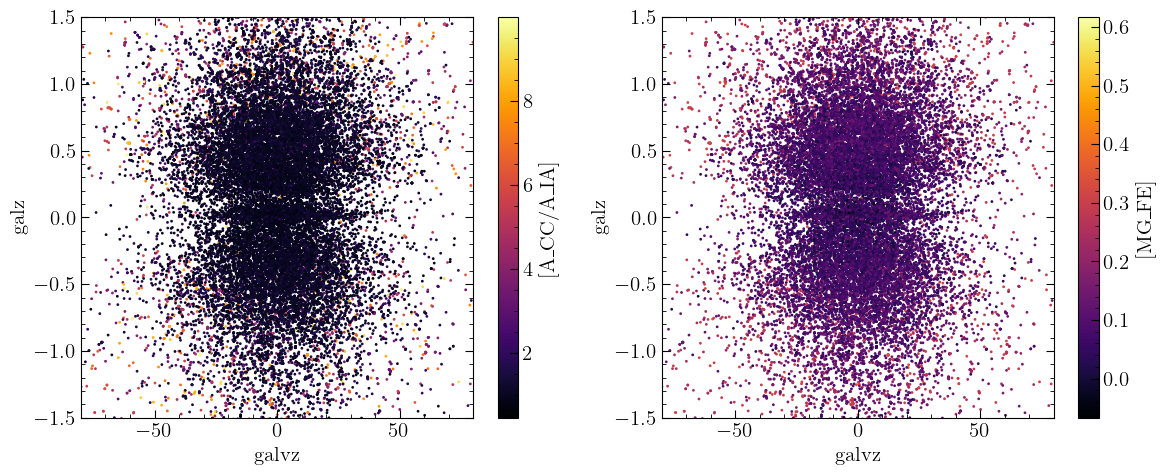

In [436]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(
    merged['galvz'],
    merged['galz'],
    c=merged['A_CC']/merged['A_IA'],   
    cmap='inferno' ,
    s = 1         
)

plt.colorbar(label='[A_CC/A_IA]')
plt.xlabel('galvz')
plt.ylabel('galz')
plt.xlim(-80,80)
plt.ylim(-1.5,1.5)


plt.subplot(1,2,2)
plt.scatter(
    merged['galvz'],
    merged['galz'],
    c=merged['MG_FE'],   
    cmap='inferno' ,
    s = 1         
)

plt.colorbar(label='[MG_FE]')
plt.xlabel('galvz')
plt.ylabel('galz')
plt.xlim(-80,80)
plt.ylim(-1.5,1.5)
plt.tight_layout()
plt.show()



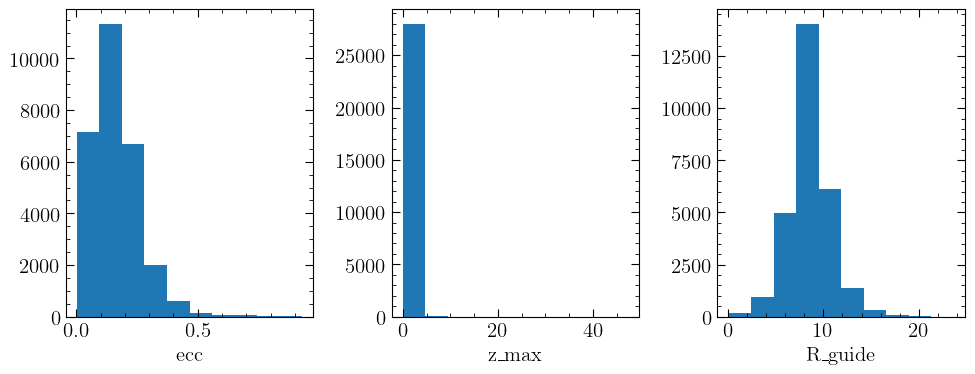

In [437]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.hist(merged['ecc'])
plt.xlabel('ecc')
mean_ecc = np.mean(merged['ecc'])
std_ecc = np.std(merged['ecc'])



plt.subplot(1,3,2)
plt.hist(merged['z_max'])
plt.xlabel("z_max")
mean_zmax = np.mean(merged['z_max'])
std_zmax = np.std(merged['z_max'])


plt.subplot(1,3,3)
plt.hist(merged['R_guide'])
plt.xlabel("R_guide")
mean_rguide = np.mean(merged['R_guide'])
std_rguide = np.std(merged['R_guide'])



plt.tight_layout()

In [438]:
sample_1 = merged[(merged['ecc'] < mean_ecc + std_ecc) & (merged['ecc'] < mean_ecc  - std_ecc)]
sample_1 = sample_1[(sample_1['z_max'] < mean_zmax + std_zmax) & (sample_1['z_max'] > mean_zmax - std_zmax)]


sample_2 = merged[(merged['ecc'] < mean_ecc + std_ecc) & (merged['ecc'] < mean_ecc  - std_ecc)]
sample_2 = sample_2[(sample_2['R_guide'] < mean_rguide + std_rguide) & (sample_2['R_guide'] > mean_rguide - std_rguide)]

sample_3 = merged[(merged['z_max'] < mean_zmax + std_zmax) & (merged['z_max'] > mean_zmax - std_zmax)]
sample_3 = sample_3[(sample_3['R_guide'] < mean_rguide + std_rguide) & (sample_3['R_guide'] > mean_rguide - std_rguide)]

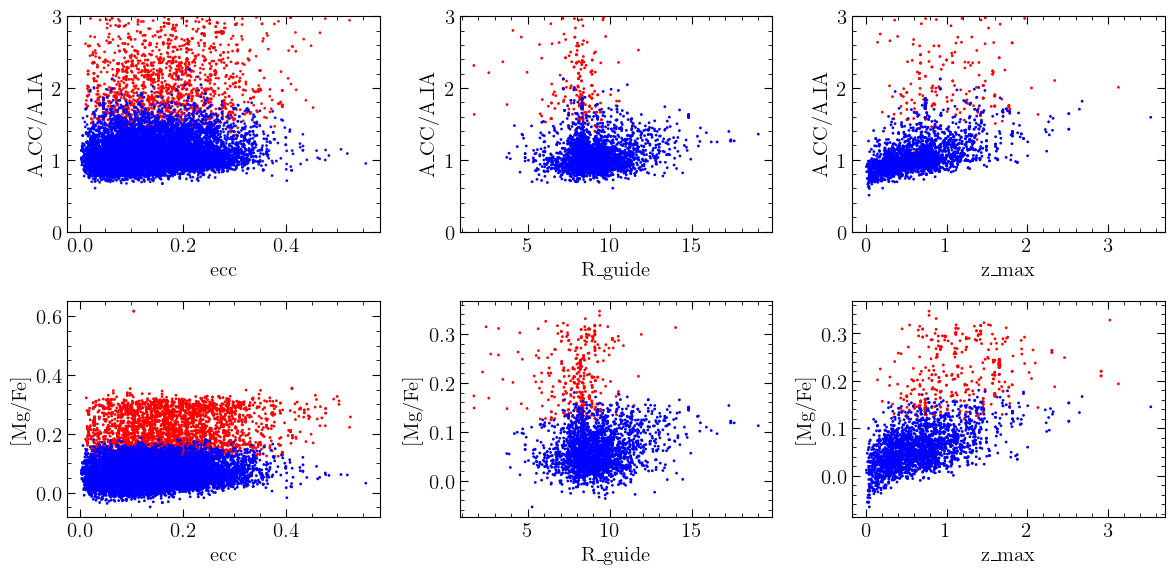

In [439]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.scatter(sample_3['ecc'], sample_3['A_CC/A_IA'], s = 1, color = sample_3['color'], alpha = 0.9)
plt.ylim(0,3)
plt.xlabel("ecc")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,2)
plt.scatter(sample_1['R_guide'], sample_1['A_CC/A_IA'], s = 1, color = sample_1['color'])
plt.ylim(0,3)
plt.xlabel("R_guide")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,3)
plt.scatter(sample_2['z_max'], sample_2['A_CC/A_IA'], s = 1, color = sample_2['color'])
plt.ylim(0,3)
plt.xlabel("z_max")
plt.ylabel("A_CC/A_IA")


plt.subplot(2,3,4)
plt.scatter(sample_3['ecc'], sample_3['MG_FE'], s = 1, color = sample_3['color'])
plt.xlabel("ecc")
plt.ylabel("[Mg/Fe]")

plt.subplot(2,3,5)
plt.scatter(sample_1['R_guide'], sample_1['MG_FE'], s = 1, color = sample_1['color'])
plt.xlabel("R_guide")
plt.ylabel("[Mg/Fe]")

plt.subplot(2,3,6)
plt.scatter(sample_2['z_max'], sample_2['MG_FE'], s = 1, color = sample_2['color'])
plt.xlabel("z_max")
plt.ylabel("[Mg/Fe]")

plt.tight_layout()

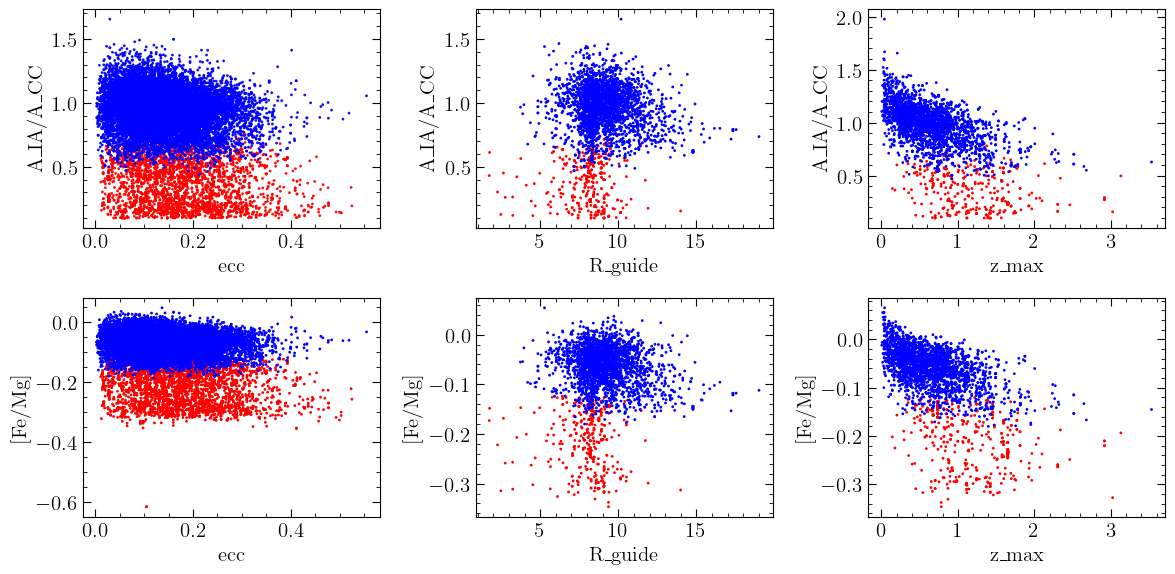

In [440]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.scatter(sample_3['ecc'], sample_3['A_IA/A_CC'], s = 1, color = sample_3['color'], alpha = 0.9)
plt.xlabel("ecc")
plt.ylabel("A_IA/A_CC")

plt.subplot(2,3,2)
plt.scatter(sample_1['R_guide'], sample_1['A_IA/A_CC'], s = 1, color = sample_1['color'])
plt.xlabel("R_guide")
plt.ylabel("A_IA/A_CC")

plt.subplot(2,3,3)
plt.scatter(sample_2['z_max'], sample_2['A_IA/A_CC'], s = 1, color = sample_2['color'])
plt.xlabel("z_max")
plt.ylabel("A_IA/A_CC")


plt.subplot(2,3,4)
plt.scatter(sample_3['ecc'], sample_3['FE_MG'], s = 1, color = sample_3['color'])
plt.xlabel("ecc")
plt.ylabel("[Fe/Mg]")

plt.subplot(2,3,5)
plt.scatter(sample_1['R_guide'], sample_1['FE_MG'], s = 1, color = sample_1['color'])
plt.xlabel("R_guide")
plt.ylabel("[Fe/Mg]")

plt.subplot(2,3,6)
plt.scatter(sample_2['z_max'], sample_2['FE_MG'], s = 1, color = sample_2['color'])
plt.xlabel("z_max")
plt.ylabel("[Fe/Mg]")

plt.tight_layout()

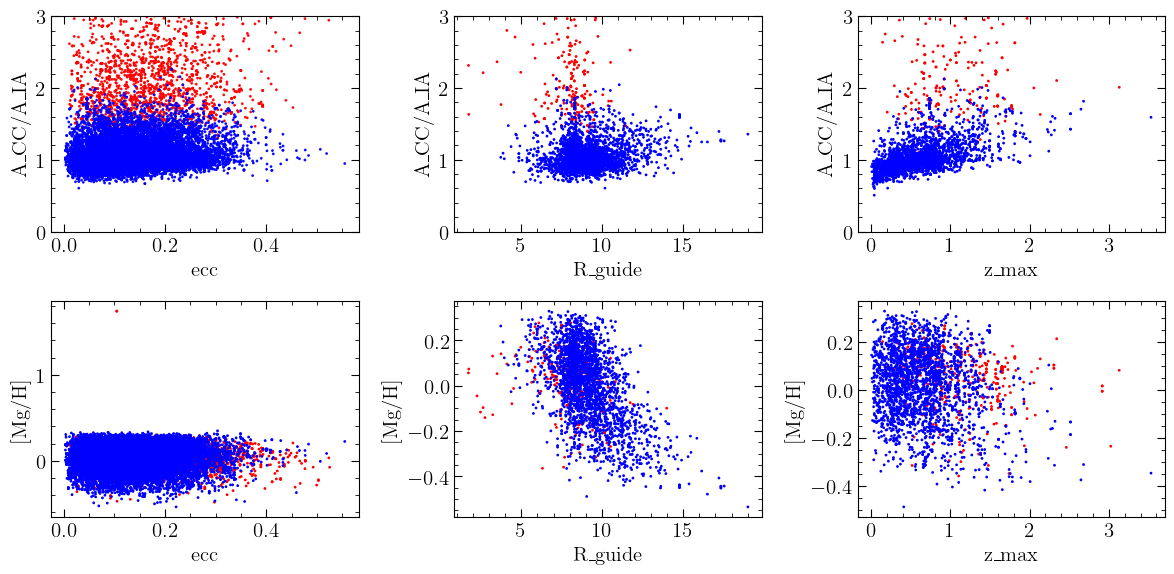

In [441]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.scatter(sample_3['ecc'], sample_3['A_CC/A_IA'], s = 1, color = sample_3['color'], alpha = 0.9)
plt.ylim(0,3)
plt.xlabel("ecc")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,2)
plt.scatter(sample_1['R_guide'], sample_1['A_CC/A_IA'], s = 1, color = sample_1['color'])
plt.ylim(0,3)
plt.xlabel("R_guide")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,3)
plt.scatter(sample_2['z_max'], sample_2['A_CC/A_IA'], s = 1, color = sample_2['color'])
plt.ylim(0,3)
plt.xlabel("z_max")
plt.ylabel("A_CC/A_IA")


plt.subplot(2,3,4)
plt.scatter(sample_3['ecc'], sample_3['MG_H'], s = 1, color = sample_3['color'])
plt.xlabel("ecc")
plt.ylabel("[Mg/H]")

plt.subplot(2,3,5)
plt.scatter(sample_1['R_guide'], sample_1['MG_H'], s = 1, color = sample_1['color'])
plt.xlabel("R_guide")
plt.ylabel("[Mg/H]")

plt.subplot(2,3,6)
plt.scatter(sample_2['z_max'], sample_2['MG_H'], s = 1, color = sample_2['color'])
plt.xlabel("z_max")
plt.ylabel("[Mg/H]")

plt.tight_layout()

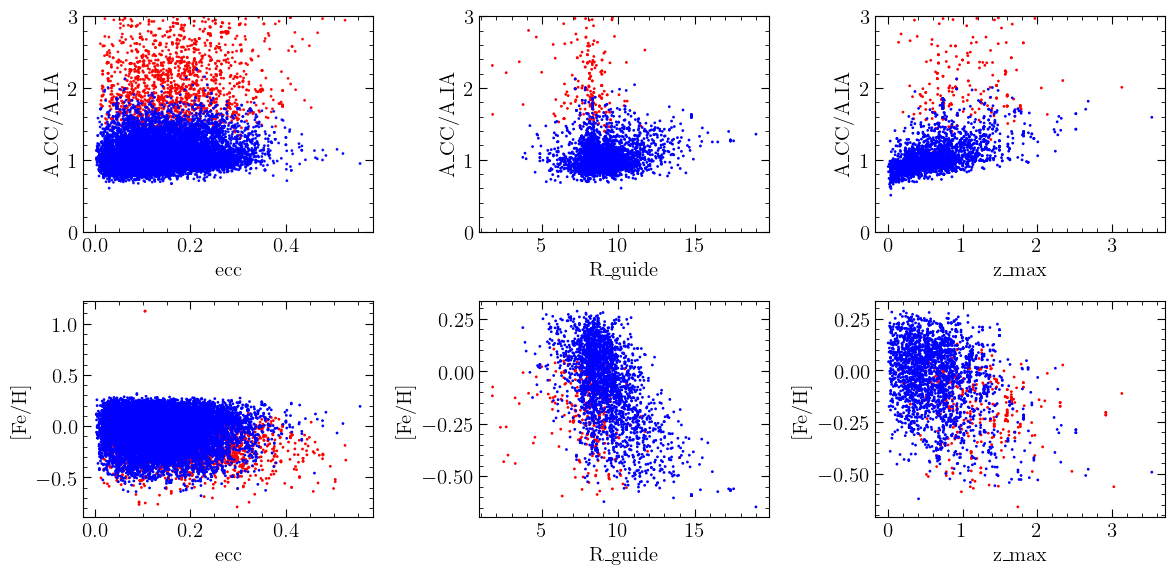

In [442]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.scatter(sample_3['ecc'], sample_3['A_CC/A_IA'], s = 1, color = sample_3['color'], alpha = 0.9)
plt.ylim(0,3)
plt.xlabel("ecc")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,2)
plt.scatter(sample_1['R_guide'], sample_1['A_CC/A_IA'], s = 1, color = sample_1['color'])
plt.ylim(0,3)
plt.xlabel("R_guide")
plt.ylabel("A_CC/A_IA")

plt.subplot(2,3,3)
plt.scatter(sample_2['z_max'], sample_2['A_CC/A_IA'], s = 1, color = sample_2['color'])
plt.ylim(0,3)
plt.xlabel("z_max")
plt.ylabel("A_CC/A_IA")


plt.subplot(2,3,4)
plt.scatter(sample_3['ecc'], sample_3['FE_H'], s = 1, color = sample_3['color'])
plt.xlabel("ecc")
plt.ylabel("[Fe/H]")

plt.subplot(2,3,5)
plt.scatter(sample_1['R_guide'], sample_1['FE_H'], s = 1, color = sample_1['color'])
plt.xlabel("R_guide")
plt.ylabel("[Fe/H]")

plt.subplot(2,3,6)
plt.scatter(sample_2['z_max'], sample_2['FE_H'], s = 1, color = sample_2['color'])
plt.xlabel("z_max")
plt.ylabel("[Fe/H]")

plt.tight_layout()

Text(0, 0.5, 'A_IA/A_CC')

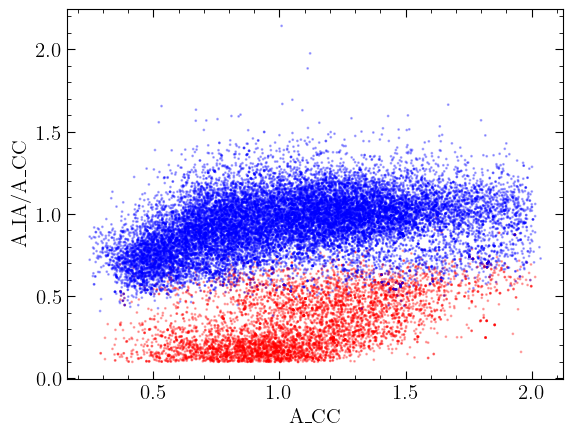

In [443]:
plt.scatter(merged['A_CC'], merged['A_IA/A_CC'], color = merged['color'], s = 1, alpha = 0.3)
plt.xlabel('A_CC')
plt.ylabel('A_IA/A_CC')

Text(0, 0.5, 'A_CC/A_IA')

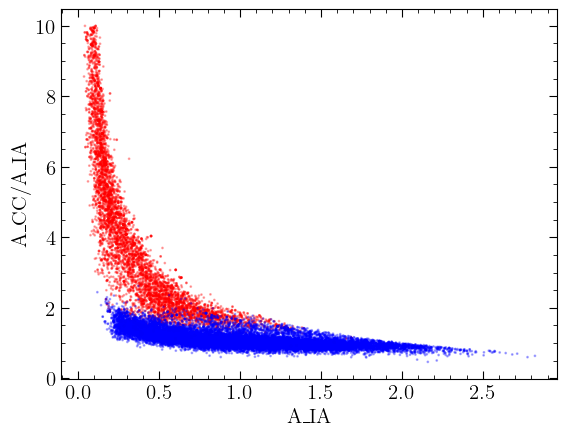

In [444]:
plt.scatter(merged['A_IA'], merged['A_CC/A_IA'], color = merged['color'], s = 1, alpha = 0.3)
plt.xlabel('A_IA')
plt.ylabel('A_CC/A_IA')

Text(0, 0.5, '[Mg/Fe]')

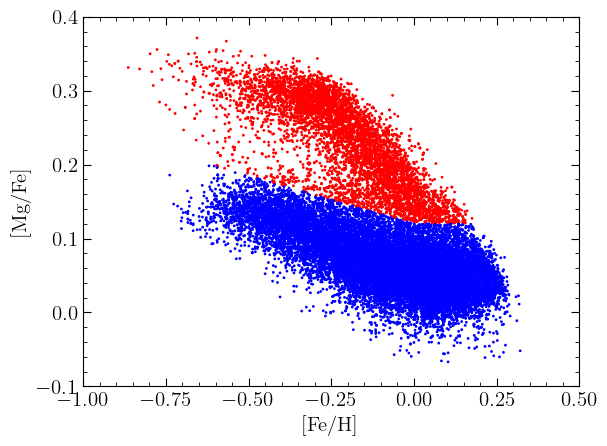

In [446]:
plt.scatter(merged['FE_H'], merged['MG_FE'], color = merged['color'], s = 1)
plt.xlim(-1, 0.5)
plt.ylim(-0.1, 0.4)
plt.xlabel("[Fe/H]")
plt.ylabel('[Mg/Fe]')